In [1]:
import operator
from typing import Annotated, TypedDict, Union

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field


load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### 실습 문제

2026년 생성형 AI 트렌드를 조사하는 Plan-and-Execute 그래프를 처음부터 구현해보자.

사용자 요청:

> 2026년 생성형 AI 트렌드를 조사하고, 주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘.


In [5]:
research_request = (
    "2026년 생성형 AI 트렌드를 조사하고, "
    "주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘. "
    "각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해줘."
)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

class State(TypedDict):
    input: str
    plans: list[str]
    results: Annotated[list, operator.add]
    response: str

class Plan(BaseModel):
    plans: list[str]

class Response(BaseModel):
    response: str

class ReplanDecision(BaseModel):
    decision: Union[Plan, Response]

In [6]:
# 계획 세우기
def planning(state: State):
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """당신을 조사 계획을 세우는 planner임
            요청 해결을 위한 조사 단계 5가지를 작성해"""
        ),
        ("human", "{input}")
    ])

    chain = prompt | llm.with_structured_output(Plan)

    response = chain.invoke({
        "input" : state["input"]
    })

    return {"plans": response.plans}
# 계획을 바탕으로 조사하기
def execute(state: State):
    current_plan = state['plans'][0]
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """당신을 조사원임
            현재 단계에 대해서만 Google Search로 조사하고, 핵심 결과와 출처 URL을 정리하세요."""
        ),
        (
        "human",
        """조사 요청:
    {input}

    현재 단계:
    {current_plan}

    이전 조사 결과:
    {results}""",
        ),
    ])

    search_llm = llm.bind_tools([{"google_search":{}}])

    chain = prompt | search_llm

    response = chain.invoke({
        "input": state["input"],
        "current_plan" : current_plan,
        "results" : "\n".join(
            f"{plan} - {text}"
            for plan, text in state.get("results", [])
        )
    })
    return {"results" : [[current_plan, response.text]]}

# 계획 수정 및 최종 응답 만들기
def replanning(state: State):
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """당신을 진행 상황 판단 replanner임
           진행 상황을 확인하고 단계가 남아 있으면 plan, 남아있지 않으면 response를 반환해."""
        ),
        (
        "human",
        """조사 요청:
    {input}

    현재 계획:
    {current_plan}

    조사 결과:
    {results}""",
        ),
    ])

    chain = prompt | llm.with_structured_output(ReplanDecision)

    response = chain.invoke({
        "input" : state["input"],
        "current_plan" :  "\n".join(state["plans"]),
        "results" : "\n".join(
            f"{plan} - {text}"
            for plan, text in state.get("results", [])
        )
    })

    if isinstance(response.decision, Response):
        return {"response" : response.decision.response}
    return {"plans" : response.decision.plans}

# 종료 할지 말지 정하기(라우터임)
def should_continue(state: State):
    return "end" if state.get("response") else "continue"

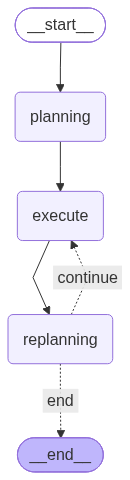

In [7]:
builer = StateGraph(State)

builer.add_node("planning",planning)
builer.add_node("execute",execute)
builer.add_node("replanning",replanning)

builer.add_edge(START, "planning")
builer.add_edge("planning", "execute")
builer.add_edge("execute", "replanning")
builer.add_conditional_edges(
    "replanning",
    should_continue,
    {
        "continue" : "execute",
        "end" : END
    }
)

graph = builer.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
# response = graph.invoke({"input" : research_request})

response = graph.invoke(
    {"input": research_request},
    config={"recursion_limit": 20}
)

print(response["response"])

2026년 생성형 AI 트렌드에 대한 조사가 완성되어, 핵심 트렌드 TOP 5와 근거, 예상 영향 및 출처를 포함한 보고서 작성이 완료되었습니다.

---

# 2026년 생성형 AI 트렌드 요약 보고서

### **1. 에이전틱 AI 및 다중 에이전트 시스템 (Agentic AI & Multiagent Systems)**
* **특징**: 단순 질문-답변(챗봇) 단계를 넘어 AI가 스스로 목표를 설정하고 업무 워크플로우를 자율적으로 계획·실행하며, 여러 AI 에이전트가 모듈화되어 협력하는 시스템입니다.
* **선정 근거**: 
  * IDC: 2027년까지 글로벌 2000대 기업의 10%가 최소 1,000개 이상의 AI 에이전트를 운영할 것으로 예측.
  * Gartner: 2026년 10대 전략 기술 트렌드로 지목하였으며, 멀티에이전트 시스템에 대한 시장 관심도가 전년 대비 1,400% 이상 폭증.
* **예상 영향**: 복잡한 업무 프로세스의 완전 자동화가 가능해지며, 인간과 AI 에이전트 간 업무 협업 구조로 조직의 IT 운영 체계가 근본적으로 재편됩니다.

#### **2. 도메인 특화 언어 모델 (Domain-Specific Language Models, DSLMs)**
* **특징**: 범용 대형언어모델(LLM)의 높은 비용, 환각 현상, 규제 대응 한계를 극복하기 위해 금융, 의료, 법률 등 특정 산업 및 업무 데이터에 특화·정밀 학습된 AI 모델입니다.
* **선정 근거**: 
  * Gartner: 2026년 도메인 특화 및 전문 생성형 AI 모델 시장 지출이 전년 대비 **210% 급증**할 것으로 전망.
  * 2028년까지 기업 내 활용되는 생성형 AI 모델의 50% 이상이 DSLM으로 전환될 것으로 예측.
* **예상 영향**: 전문 영역에서의 AI 응답 정확도, 설명 가능성, 법적 규제 준수력이 비약적으로 향상되며 기업들의 실제 ROI 달성을 가속화합니다.

#### **3. AI 네이티브 개발 플랫폼 (AI-Native Develo

### 추가 실습: Replanner 없는 Plan-and-Execute

Replanner는 Plan-and-Execute의 필수 구성요소가 아니다. 초기 계획을 수정할 필요가 없다면 Planner가 만든 계획을 그대로 실행할 수 있다.

앞에서 구현한 여행 계획 그래프에서 Replanner를 제거하고, Planner가 처음 만든 계획을 순서대로 모두 실행하도록 수정해보자.

> 힌트: Executor가 현재 단계를 실행한 뒤 `{"plan": state["plan"][1:]}`을 반환하면 완료한 단계를 계획에서 제거할 수 있다. `plan`이 비었는지를 기준으로 Executor와 최종 응답 생성 노드 사이를 분기할 수 있다.

In [11]:
research_request = (
    "2026년 생성형 AI 트렌드를 조사하고, "
    "주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘. "
    "각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해줘."
)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

class State(TypedDict):
    input: str
    plans: list[str]
    results: Annotated[list, operator.add]
    response: str

class Plan(BaseModel):
    plans: list[str]

class Response(BaseModel):
    response: str


# 계획 세우기
def planning(state: State):
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """당신을 조사 계획을 세우는 planner임
            요청 해결을 위한 조사 단계 5가지를 작성해"""
        ),
        ("human", "{input}")
    ])

    chain = prompt | llm.with_structured_output(Plan)

    response = chain.invoke({
        "input" : state["input"]
    })

    return {"plans": response.plans}
# 계획을 바탕으로 조사하기
def execute(state: State):
    current_plan = state['plans'][0]
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """당신을 조사원임
            현재 단계에 대해서만 Google Search로 조사하고, 핵심 결과와 출처 URL을 정리하세요."""
        ),
        (
        "human",
        """조사 요청:
    {input}

    현재 단계:
    {current_plan}

    이전 조사 결과:
    {results}""",
        ),
    ])

    search_llm = llm.bind_tools([{"google_search":{}}])

    chain = prompt | search_llm

    response = chain.invoke({
        "input": state["input"],
        "current_plan" : current_plan,
        "results" : "\n".join(
            f"{plan} - {text}"
            for plan, text in state.get("results", [])
        )
    })
    return {"results" : [[current_plan, response.text]],
            "plans": state["plans"][1:]}



# 종료 할지 말지 정하기(라우터임)
def should_continue(state: State):
    return "continue" if state.get("plans") else "final"


def final(state: State):
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """당신은 최종 결과를 만드는 보고서 작성인원이야
            지금까지 결과를 바탕으로 보고서를 만들어"""
        ),
        (
        "human",
        """조사 요청:
    {input}

    전체 결과:
    {results}""",
        ),
    ])

    chain = prompt | llm

    response = chain.invoke({
        'input' : state['input'],
        'results' : "\n".join(
            f"- {step}: {step_result}"
            for step, step_result in state["results"]
        )        
    })
    return {"response" : response.text}

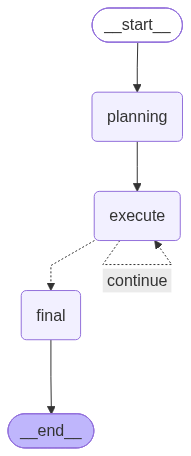

In [12]:
builer = StateGraph(State)

builer.add_node("planning", planning)
builer.add_node("execute", execute)
builer.add_node("final", final)

builer.add_edge(START, "planning")
builer.add_edge("planning", "execute")

builer.add_conditional_edges(
    "execute",
    should_continue,
    {
        "continue" : "execute",
        "final" : "final"
    }
)

builer.add_edge("final", END)

graph = builer.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [13]:
response = graph.invoke(
    {"input": research_request},
    config={"recursion_limit": 20}
)

print(response["response"])

# [최종 요약 보고서] 2026년 글로벌 생성형 AI 5대 트렌드 분석 및 엔터프라이즈 대응 전략

---

## 1. 개요 및 핵심 요약 (Executive Summary)

2026년 생성형 AI(Generative AI) 시장은 단순 텍스트 작성 및 보조용 챗봇(Assistant) 수준의 **기술 검증(PoC) 단계를 완전히 넘어, 실질적 ROI 및 자율 실행 중심의 전면적인 산업 적용 단계**에 진입했습니다. 

Gartner, Deloitte, McKinsey, IDC 등 글로벌 리서치 기관의 종합 분석 결과, 2026년 생성형 AI 시장의 핵심 메가 트렌드는 **① 에이전틱 AI**, **② 피지컬 AI**, **③ 도메인 특화 모델**, **④ 기본 사양화된 멀티모달 및 GEO**, **⑤ 저전력 인프라 및 소버린 거버넌스**로 축약됩니다.

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│                          2026년 생성형 AI 5대 핵심 메가 트렌드                            │
├────────────────────────────────────────────────────────────────────────────────────────┤
│ 1. Agentic AI & Multi-Agent Systems    : 자율 목표 수립 및 실행 중심의 디지털 인력화      │
│ 2. Physical AI & Robotics Integration  : 가상 SW를 넘어 로보틱스·물리계로의 전면 이식      │
│ 3. Domain-Specific Models & Applied AI : 초거대 범용 모델 탈피, 고효율·보안형 SLM 전환   │
│ 4. Multimodal by Default & GEO         : 음성/영상 네이티브 인터페이스 및 생성형 검색 최적화│
